In [1]:
import numpy as np
import matplotlib.pyplot as plt

from game_parameters import (
    WORLD_PATHS,
    ASSETS_PATHS,
)
from helper_classes import World

In [16]:
world_types = ["circular", "linear_down", "linear_up", "random"]
idx = 1  # Change index to create different worlds

world_parameters = {
    "num_coins": 150,
    "num_centroids": 20,
    "dispersion": 1,
    "distribution": world_types[idx],
    "random_coins":0.15,
    "x_bias":25,
    "y_bias":-10,
}
world = World(**world_parameters)
world.map_path = WORLD_PATHS[idx]
world.coin_path = ASSETS_PATHS["coin_url"]
world.forager_path = ASSETS_PATHS["forager_url"]


World with 91.0 coins generated


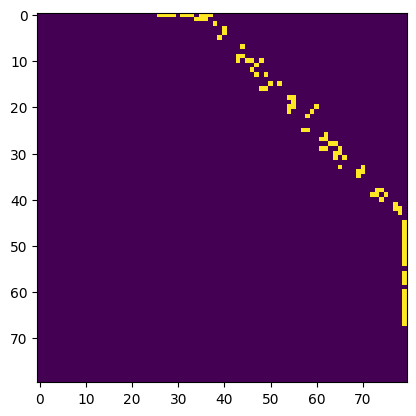

In [17]:
full_view = world.generate_rgba_array()
print(f"World with {world.count_coins()} coins generated")
plt.imshow(full_view)

In [ ]:
# import json

# map_url = "static/investment_test.json"
# with open(map_url, "w", encoding="utf-8") as f:
#     json.dump(full_view, f)

In [ ]:
# world.save_world()

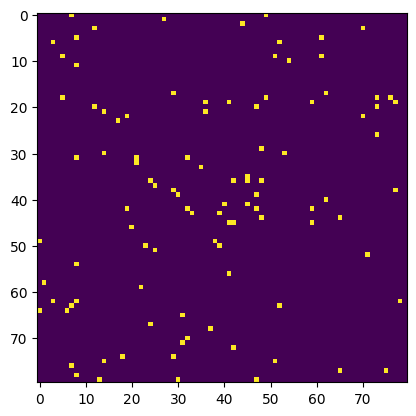

In [32]:
view = world.coordinator_view(information_investment=0.6)
plt.imshow(view)

In [ ]:
world.render(coin_zoom=0.005)

In [ ]:
fig, ax = plt.subplots(
    figsize=(8, 5),
    dpi=100
)
world.show_bots(
    locations=[(25, 25), (20, 15), (5, 5)], 
    max_distance=17,
    ax=ax
)
# fig.savefig("reach_gear_3.png")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from helper_classes import World
from game_parameters import (
    WORLD_PATHS,
    ASSETS_PATHS,
)

idx = 0
world1 = World.generate_from_json(WORLD_PATHS[idx])
terrain1 = world1.generate_terrain()
plt.imshow(terrain1)

In [ ]:
from helper_classes import ForagerBot
from game_parameters import COLLECTION_CHANCE, MAX_MOVEMENT

start_pos = (25, 15)
max_speed = 3

bot = ForagerBot(
    grid=world1.grid.copy(), 
    start=start_pos,
    max_speed=max_speed,
)
steps = bot.run(
    fuel_steps=MAX_MOVEMENT(max_speed),
    max_turns=MAX_MOVEMENT(max_speed),
)
chance = COLLECTION_CHANCE(max_speed)

print("Turns:", bot.turn)
print("Visited:", len(bot.visited))
print("Collection chance:", chance)
print("Collected:", len(bot.collected))
print("Final pos:", bot.pos)

world_coins = world1.coin_positions().copy()
world1.remove_given_coins(bot.collected)
world1.show_bots(
    locations=[start_pos, bot.pos], 
    max_distance=10,
)
world1.place_given_coins(world_coins)

In [ ]:
world1.count_coins()

In [ ]:
removed = world1.bot_collect(
    available_coins=world1.coin_positions(),
    location=(35, 35), 
    collection_probability=0.9,
    max_distance=35,
)
print("Num. of coins removed:", len(removed))

In [ ]:
terrain1 = world1.generate_terrain()
plt.imshow(terrain1)

In [ ]:
new_coins = [coin for coin in world1.coin_positions() if coin not in removed]
world3 = World.generate_from_coins(new_coins)
terrain3 = world3.generate_terrain()
plt.imshow(terrain3)

In [ ]:
world3.count_coins()

In [ ]:
import numpy as np

X = np.linspace(0, 1, 1000)
Y = np.vectorize(lambda x: World.get_probability_of_view(
    x,
    threshold=0.8,
    steepness=15.0,
    min_value=0.02,
    proportion=1.0,
))(X)

plt.ylim([0, 1])
plt.plot(X, Y)
plt.grid()

In [ ]:
world.threshold = 0.7
world.steepness = 15.0
world.min_value = 0.02
world.proportion = 1.0
image = world.coordinator_view(0.6)

fig, ax = plt.subplots(1, 1)
ax.imshow(image)
ax.set_axis_off()

In [ ]:
world1.count_coins()